# CIFAR-10 classification: from a small CNN to transfer learning

A series of experiments on CIFAR-10 (10 classes, 32x32 RGB images) in PyTorch. Every section changes one thing --
data augmentation, learning-rate schedule, architecture, pretrained weights -- and records the validation and test
accuracy, so the effect of each change is visible.

> **About the comments.** The explanatory comments and section headings in this notebook were written with the help of
> Claude (an AI assistant by Anthropic) to make it easier to navigate. The experiments and the code are the author's.

## Contents and results

Accuracy is measured on the validation split (last epoch) and on the test set. The test set was evaluated after each
experiment, so it was also used (informally) to compare experiments.

| # | Experiment | Valid acc | Test acc |
|---|------------|-----------|----------|
| 1 | Small CNN (2 conv blocks), no augmentation, Adam | 0.6374 | not evaluated |
| 2 | 5-conv CNN + flip / crop augmentation, ReduceLROnPlateau | 0.8648 | 0.8642 |
| 3 | + ColorJitter, RandomErasing, weight decay 5e-4 | 0.8626 | 0.8610 |
| 4 | + cosine annealing LR | 0.8649 | 0.8620 |
| 5 | Residual network (custom), Adam + cosine | 0.8708 | 0.8682 |
| 6 | Same network, SGD + momentum, 80 epochs | 0.8816 | 0.8784 |
| 7 | ResNet-18-style network (custom), SGD + momentum | 0.8927 | 0.8907 |
| 8 | **ResNet-18 pretrained on ImageNet, full fine-tuning** | **0.9203** | **0.9115** |
| 9 | Pretrained ResNet-18, first 7 children frozen | 0.8907 | kernel crashed |
| 10 | Pretrained DenseNet-121 | not completed | not completed |

**Notes.** The cells were executed across several kernel sessions, so the execution counts were reset; the stored
outputs are the recorded runs. All training cells expect a CUDA GPU.

In [ ]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from pathlib import Path
from PIL import Image

## 0. Setup and data

Expected folder layout -- CIFAR-10 stored as image folders (not included in this repository):

```
data/cifar10/
  train/<class_name>/*.jpg    # 50,000 images, 5,000 per class
  test/<class_name>/*.jpg     # 10,000 images
```

Point `DATA_ROOT` in the next cell to your copy.

In [ ]:
# Root folder of the CIFAR-10 image-folder copy: DATA_ROOT/{train,test}/<class_name>/<image>.jpg
DATA_ROOT = Path('data/cifar10')
TRAIN_DATA_PATH = DATA_ROOT / 'train'
TEST_DATA_PATH = DATA_ROOT / 'test'


In [ ]:
# Sanity check: number of entries (class folders + images) under train and test
folder_path = TRAIN_DATA_PATH
total_objects = len(list(folder_path.rglob("*")))
print(f"Total objects inside train: {total_objects}")

folder_path = TEST_DATA_PATH
total_objects = len(list(folder_path.rglob("*")))
print(f"Total objects inside test: {total_objects}")


Total objects inside train: 50010
Total objects inside test: 10010


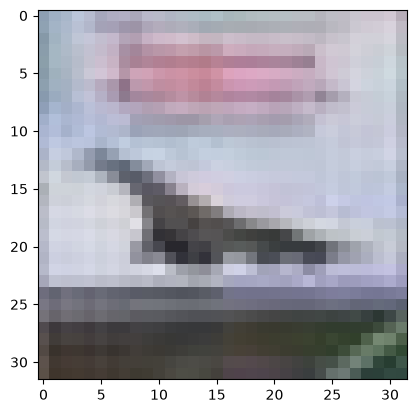

In [ ]:
# Look at a sample test image (32x32 RGB)
img = np.asarray(Image.open(TEST_DATA_PATH / "airplane" / "0000.jpg"))
plt.imshow(img)
plt.show()


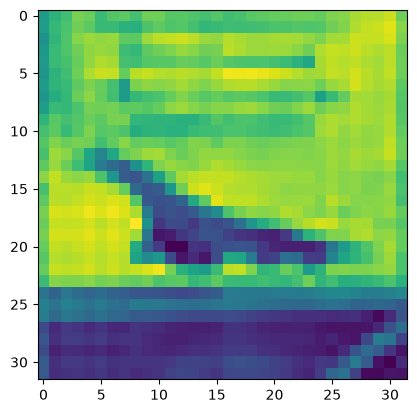

In [ ]:
# Show only the first (red) channel as a single-channel map
img = np.asarray(Image.open(TEST_DATA_PATH / "airplane" / "0000.jpg"))
lum_img = img[:, :, 0]
plt.imshow(lum_img)
plt.show()


## 1. Baseline: small CNN, no augmentation

Only `ToTensor` preprocessing, an 80 / 20 train / validation split of the training folder and a small CNN
(2 conv blocks + MLP head). It overfits quickly: at the last epoch the train loss is 0.405 but the validation loss is
1.133 (valid accuracy 0.6374).

In [ ]:
# Baseline preprocessing: only ToTensor (pixels scaled to [0, 1]); no normalization, no augmentation
transform = transforms.ToTensor()
train_dataset = datasets.ImageFolder(TRAIN_DATA_PATH, transform=transform)
test_dataset = datasets.ImageFolder(TEST_DATA_PATH, transform=transform)

In [ ]:
# Hold out 20% of the training folder as a validation set (random split without a fixed seed)
train_dataset, valid_dataset = torch.utils.data.random_split(train_dataset, [0.8, 0.2])

In [ ]:
# Batched data loaders (shuffle only the training set)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
# Baseline model: 2 x (Conv -> BatchNorm -> ReLU -> MaxPool) followed by a small MLP head
class ClassificationCNN(nn.Module):
    def __init__(self):
        
        super().__init__()

        self.network = nn.Sequential(nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),
                                     nn.BatchNorm2d(16),
                                     nn.ReLU(),
                                     nn.MaxPool2d(kernel_size=2),
                                    

                                     nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
                                     nn.BatchNorm2d(32),
                                     nn.ReLU(),
                                     nn.MaxPool2d(kernel_size=2),
                                     
                                     
                                     # 32x32 -> 16x16 -> 8x8 after two poolings, hence 8*8*32 features below
                                     nn.Flatten(),
                                     nn.Dropout(0.3),
                                     nn.Linear(in_features=8*8*32, out_features=128),
                                     nn.ReLU(),
                                     nn.Linear(in_features=128, out_features=10)
                                    )

    def forward(self, x):
        return self.network(x)

In [ ]:
# Accuracy metric from torchmetrics
from torchmetrics.classification import MulticlassAccuracy

In [ ]:
# Train the model (Adam, lr=1e-4, weight decay 1e-3, 60 epochs)
# Model, loss, optimizer and metric all live on the GPU (a CUDA device is required)
model = ClassificationCNN().to('cuda')
loss_fn = nn.CrossEntropyLoss().to('cuda')
optimizer = torch.optim.Adam(params=model.parameters(), lr=1e-4, weight_decay=1e-3)
accuracy = MulticlassAccuracy(num_classes=10).to('cuda')

# Number of passes over the training set
epochs = 60

# Per-epoch history used for the loss curves
train_loss = []
valid_loss = []


# One epoch = a training pass followed by a validation pass
for epoch in range(epochs):
    train_sum_loss = 0
    val_sum_loss = 0

    # Training mode: dropout active, BatchNorm uses batch statistics
    model.train()
    for train_images, train_labels in train_loader:
        train_images = train_images.to('cuda')
        train_labels = train_labels.to('cuda')
        # Forward pass
        train_predictions = model(train_images)
        tr_loss = loss_fn(train_predictions, train_labels)
        # Backward pass and parameter update
        optimizer.zero_grad()
        tr_loss.backward()
        optimizer.step()
        train_sum_loss += tr_loss.item()

    # Evaluation mode: no dropout, BatchNorm uses running statistics
    model.eval()

    # No gradients are needed for validation
    with torch.inference_mode():
        for valid_images, valid_labels in valid_loader:
            valid_images = valid_images.to('cuda')
            valid_labels = valid_labels.to('cuda')
            valid_predictions = model(valid_images)
            val_loss = loss_fn(valid_predictions, valid_labels)
            val_sum_loss += val_loss.item()
            # Accumulate accuracy over all validation batches
            accuracy.update(valid_predictions, valid_labels)

    # Average the losses over batches
    avg_train_loss = train_sum_loss / len(train_loader)
    avg_val_loss = val_sum_loss / len(valid_loader)
    train_loss.append(avg_train_loss)
    valid_loss.append(avg_val_loss)
    # Accuracy over the whole validation set for this epoch
    acc = accuracy.compute()

    
    print(f'Epoch: {epoch} | Train loss: {avg_train_loss:.4f} | Valid loss: {avg_val_loss:.4f} | Accuracy: {acc:.4f}')

    # Reset the metric for the next epoch
    accuracy.reset()


Epoch: 0 | Train loss: 1.8609 | Valid loss: 1.5767 | Accuracy: 0.4578
Epoch: 1 | Train loss: 1.5561 | Valid loss: 1.4451 | Accuracy: 0.4859
Epoch: 2 | Train loss: 1.4318 | Valid loss: 1.3501 | Accuracy: 0.5299
Epoch: 3 | Train loss: 1.3469 | Valid loss: 1.3122 | Accuracy: 0.5478
Epoch: 4 | Train loss: 1.2772 | Valid loss: 1.2473 | Accuracy: 0.5692
Epoch: 5 | Train loss: 1.2305 | Valid loss: 1.2312 | Accuracy: 0.5674
Epoch: 6 | Train loss: 1.1868 | Valid loss: 1.2137 | Accuracy: 0.5776
Epoch: 7 | Train loss: 1.1499 | Valid loss: 1.2309 | Accuracy: 0.5664
Epoch: 8 | Train loss: 1.1145 | Valid loss: 1.1897 | Accuracy: 0.5904
Epoch: 9 | Train loss: 1.0785 | Valid loss: 1.1582 | Accuracy: 0.5942
Epoch: 10 | Train loss: 1.0445 | Valid loss: 1.1402 | Accuracy: 0.6017
Epoch: 11 | Train loss: 1.0221 | Valid loss: 1.1407 | Accuracy: 0.5968
Epoch: 12 | Train loss: 0.9933 | Valid loss: 1.1192 | Accuracy: 0.6052
Epoch: 13 | Train loss: 0.9774 | Valid loss: 1.1371 | Accuracy: 0.6086
Epoch: 14 | Trai

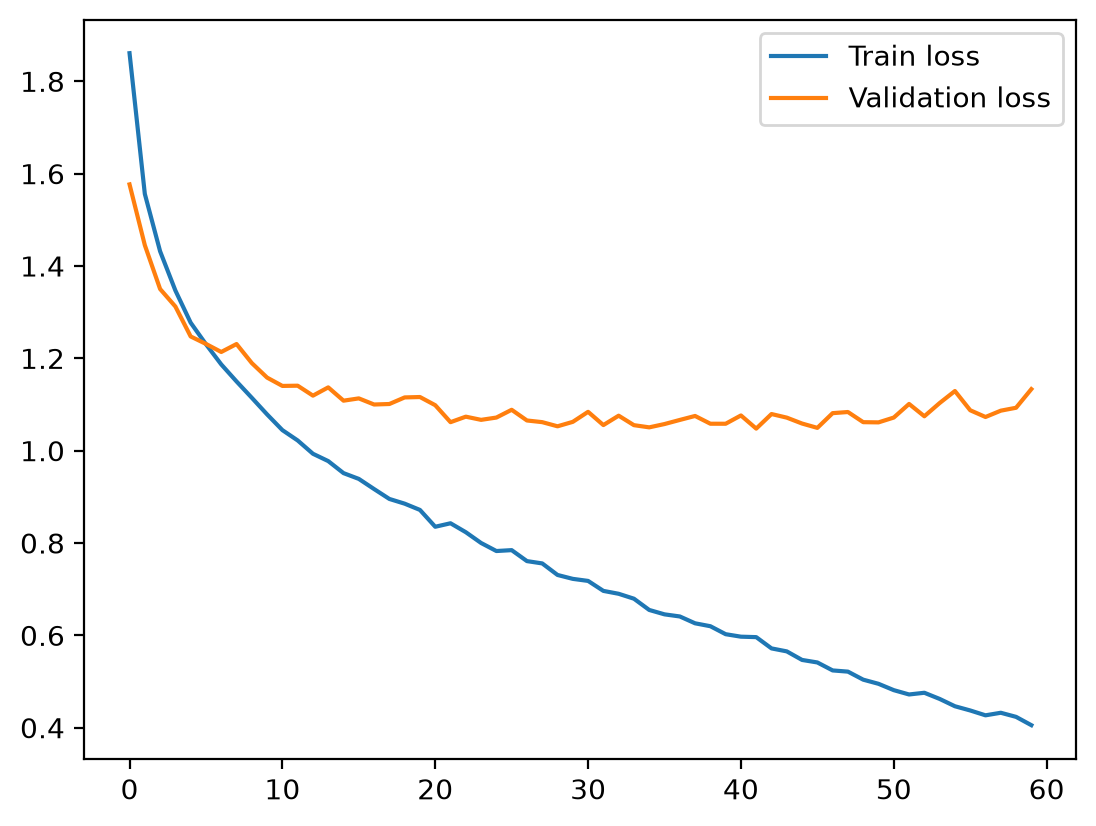

In [ ]:
# Loss curves: a growing gap between train and validation loss signals overfitting
plt.figure(dpi=200)
plt.plot(np.arange(0, 60), train_loss, label='Train loss')
plt.plot(np.arange(0, 60), valid_loss, label='Validation loss')
plt.legend()
plt.show()

## 2. Deeper CNN + augmentation + ReduceLROnPlateau

Five conv layers with BatchNorm, random horizontal flip and random crop (padding 4), channel-wise normalization, and
a scheduler that halves the learning rate when the validation loss plateaus.
Valid accuracy 0.8648, test accuracy 0.8642.

In [ ]:
# Data augmentation
import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, random_split

# 1. Define the transforms (ToTensor is part of the pipeline; normalize with CIFAR-10 channel mean / std)
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

valid_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

# 2. Load the image folders, each with its own transforms
ds_train_full = datasets.ImageFolder(TRAIN_DATA_PATH, transform=train_transform)
ds_valid_full = datasets.ImageFolder(TRAIN_DATA_PATH, transform=valid_transform)

# 3. Fix the random seed so that both splits use the same indices
generator = torch.Generator().manual_seed(42)

# 4. Split: the 80% part comes from the augmented dataset (train), the 20% part from the plain one (valid)
train_dataset, _ = random_split(
    ds_train_full, 
    [0.8, 0.2], 
    generator=torch.Generator().manual_seed(42)
)

_, valid_dataset = random_split(
    ds_valid_full, 
    [0.8, 0.2], 
    generator=torch.Generator().manual_seed(42) # Reset to the same seed (42) so the indices match the train split
)

test_dataset = datasets.ImageFolder(TEST_DATA_PATH, transform=valid_transform)

# 5. Data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
class ClassificationCNN(nn.Module):

    def __init__(self):
        
        super().__init__()

        self.network = nn.Sequential(nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),
                                     nn.BatchNorm2d(16),
                                     nn.ReLU(),
                                    
                                     nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
                                     nn.BatchNorm2d(32),
                                     nn.ReLU(),
                                     
                                     nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
                                     nn.BatchNorm2d(64),
                                     nn.ReLU(),
                                     nn.MaxPool2d(kernel_size=2),

                                     nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
                                     nn.BatchNorm2d(128),
                                     nn.ReLU(),
                                     nn.MaxPool2d(kernel_size=2),

                                     nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
                                     nn.BatchNorm2d(256),
                                     nn.ReLU(),
                                     nn.AdaptiveAvgPool2d((2, 2)),

                                     
                                     nn.Flatten(),
                                     nn.Linear(in_features=1024, out_features=128),
                                     nn.BatchNorm1d(128),
                                     nn.ReLU(),
                                     nn.Dropout(0.4),
                                     nn.Linear(in_features=128, out_features=10)
                                    )

    def forward(self, x):
        return self.network(x)

In [ ]:
# Same loop as in section 1. Changes: deeper model, lr=1e-3, weight_decay=1e-4, ReduceLROnPlateau
# (scheduler.step(avg_val_loss) at the end of every epoch), 40 epochs.
# Train the model
model = ClassificationCNN().to('cuda')
loss_fn = nn.CrossEntropyLoss().to('cuda')
optimizer = torch.optim.Adam(params=model.parameters(), lr=1e-3, weight_decay=1e-4)
accuracy = MulticlassAccuracy(num_classes=10).to('cuda')
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
) # Scheduler: lowers the learning rate when the validation loss stops improving

epochs = 40

train_loss = []
valid_loss = []


for epoch in range(epochs):
    train_sum_loss = 0
    val_sum_loss = 0

    model.train()
    for train_images, train_labels in train_loader:
        train_images = train_images.to('cuda')
        train_labels = train_labels.to('cuda')
        train_predictions = model(train_images)
        tr_loss = loss_fn(train_predictions, train_labels)
        optimizer.zero_grad()
        tr_loss.backward()
        optimizer.step()
        train_sum_loss += tr_loss.item()

    model.eval()

    with torch.inference_mode():
        for valid_images, valid_labels in valid_loader:
            valid_images = valid_images.to('cuda')
            valid_labels = valid_labels.to('cuda')
            valid_predictions = model(valid_images)
            val_loss = loss_fn(valid_predictions, valid_labels)
            val_sum_loss += val_loss.item()
            accuracy.update(valid_predictions, valid_labels)

    avg_train_loss = train_sum_loss / len(train_loader)
    avg_val_loss = val_sum_loss / len(valid_loader)
    train_loss.append(avg_train_loss)
    valid_loss.append(avg_val_loss)
    acc = accuracy.compute()

    
    print(f'Epoch: {epoch+1} | Train loss: {avg_train_loss:.4f} | Valid loss: {avg_val_loss:.4f} | Accuracy: {acc:.4f}')

    accuracy.reset()
    scheduler.step(avg_val_loss)

Epoch: 1 | Train loss: 1.4072 | Valid loss: 1.2727 | Accuracy: 0.5599
Epoch: 2 | Train loss: 1.0763 | Valid loss: 0.9618 | Accuracy: 0.6606
Epoch: 3 | Train loss: 0.9631 | Valid loss: 0.8256 | Accuracy: 0.7070
Epoch: 4 | Train loss: 0.8857 | Valid loss: 0.7529 | Accuracy: 0.7318
Epoch: 5 | Train loss: 0.8216 | Valid loss: 0.7192 | Accuracy: 0.7448
Epoch: 6 | Train loss: 0.7723 | Valid loss: 0.6907 | Accuracy: 0.7607
Epoch: 7 | Train loss: 0.7345 | Valid loss: 0.6371 | Accuracy: 0.7784
Epoch: 8 | Train loss: 0.7073 | Valid loss: 0.6290 | Accuracy: 0.7834
Epoch: 9 | Train loss: 0.6770 | Valid loss: 0.6350 | Accuracy: 0.7827
Epoch: 10 | Train loss: 0.6518 | Valid loss: 0.5977 | Accuracy: 0.7962
Epoch: 11 | Train loss: 0.6296 | Valid loss: 0.5980 | Accuracy: 0.7946
Epoch: 12 | Train loss: 0.6048 | Valid loss: 0.5922 | Accuracy: 0.7990
Epoch: 13 | Train loss: 0.5919 | Valid loss: 0.5722 | Accuracy: 0.8040
Epoch: 14 | Train loss: 0.5718 | Valid loss: 0.5664 | Accuracy: 0.8046
Epoch: 15 | Tra

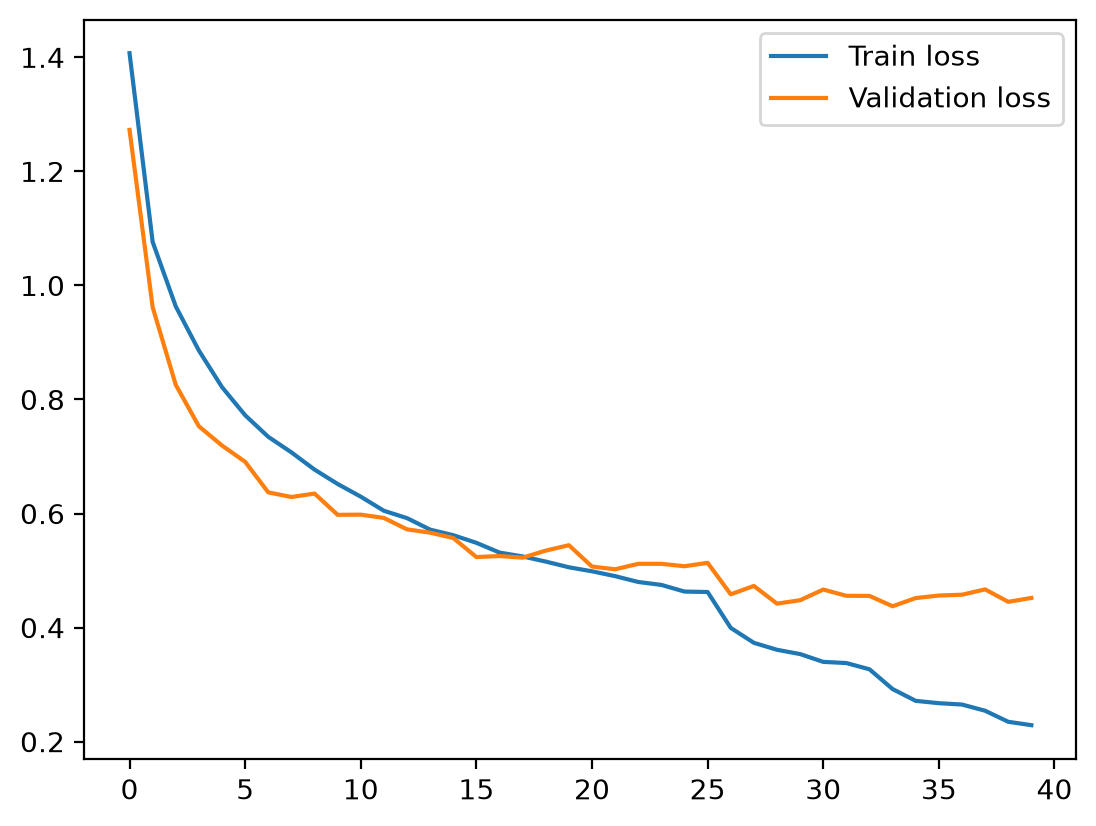

In [ ]:
plt.figure(dpi=200)
plt.plot(np.arange(0, 40), train_loss, label='Train loss')
plt.plot(np.arange(0, 40), valid_loss, label='Validation loss')
plt.legend()
plt.show()

In [ ]:
# Evaluate the trained model on the test set
test_sum_loss = 0
model.eval()
with torch.inference_mode():
    for test_images, test_labels in test_loader:
        test_images = test_images.to('cuda')
        test_labels = test_labels.to('cuda')
        test_predictions = model(test_images)
        test_loss = loss_fn(test_predictions, test_labels)
        test_sum_loss += test_loss.item()
        accuracy.update(test_predictions, test_labels)

avg_test_loss = test_sum_loss/len(test_loader)
acc = accuracy.compute()
print(f'Test loss: {avg_test_loss} | Accuracy: {acc}')
accuracy.reset()

Test loss: 0.4355736628960306 | Accuracy: 0.8641999959945679


## 3. Stronger augmentation

Adds `ColorJitter` and `RandomErasing` and raises the weight decay to 5e-4.
Valid accuracy 0.8626, test accuracy 0.8610 -- no improvement over experiment 2 for this model.

In [ ]:
'''Stronger augmentation'''
# 1. Training transforms with stronger regularization
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomCrop(32, padding=4),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.2), value='random') # Randomly erase a rectangular patch
])

# 2. Validation / test transforms (no distortion)
valid_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

# 3. Load the source datasets
ds_train_full = datasets.ImageFolder(TRAIN_DATA_PATH, transform=train_transform)
ds_valid_full = datasets.ImageFolder(TRAIN_DATA_PATH, transform=valid_transform)

# 4. Reproducible train / valid split (isolated generators with the same seed)
train_dataset, _ = random_split(
    ds_train_full, 
    [0.8, 0.2], 
    generator=torch.Generator().manual_seed(42)
)

_, valid_dataset = random_split(
    ds_valid_full, 
    [0.8, 0.2], 
    generator=torch.Generator().manual_seed(42)
)

test_dataset = datasets.ImageFolder(TEST_DATA_PATH, transform=valid_transform)

# 5. Data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
class ClassificationCNN(nn.Module):

    def __init__(self):
        
        super().__init__()

        self.network = nn.Sequential(nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),
                                     nn.BatchNorm2d(16),
                                     nn.ReLU(),
                                    
                                     nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
                                     nn.BatchNorm2d(32),
                                     nn.ReLU(),
                                     
                                     nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
                                     nn.BatchNorm2d(64),
                                     nn.ReLU(),
                                     nn.MaxPool2d(kernel_size=2),

                                     nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
                                     nn.BatchNorm2d(128),
                                     nn.ReLU(),
                                     nn.MaxPool2d(kernel_size=2),

                                     nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
                                     nn.BatchNorm2d(256),
                                     nn.ReLU(),
                                     nn.AdaptiveAvgPool2d((2, 2)),

                                     
                                     nn.Flatten(),
                                     nn.Linear(in_features=1024, out_features=128),
                                     nn.BatchNorm1d(128),
                                     nn.ReLU(),
                                     nn.Dropout(0.4),
                                     nn.Linear(in_features=128, out_features=10)
                                    )

    def forward(self, x):
        return self.network(x)

In [ ]:
# Same loop. Changes: weight_decay=5e-4 and the stronger augmentation defined above.
# Train the model
model = ClassificationCNN().to('cuda')
loss_fn = nn.CrossEntropyLoss().to('cuda')
optimizer = torch.optim.Adam(params=model.parameters(), lr=1e-3, weight_decay=5e-4)
accuracy = MulticlassAccuracy(num_classes=10).to('cuda')
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
) # Scheduler: lowers the learning rate when the validation loss stops improving

epochs = 40

train_loss = []
valid_loss = []


for epoch in range(epochs):
    train_sum_loss = 0
    val_sum_loss = 0

    model.train()
    for train_images, train_labels in train_loader:
        train_images = train_images.to('cuda')
        train_labels = train_labels.to('cuda')
        train_predictions = model(train_images)
        tr_loss = loss_fn(train_predictions, train_labels)
        optimizer.zero_grad()
        tr_loss.backward()
        optimizer.step()
        train_sum_loss += tr_loss.item()

    model.eval()

    with torch.inference_mode():
        for valid_images, valid_labels in valid_loader:
            valid_images = valid_images.to('cuda')
            valid_labels = valid_labels.to('cuda')
            valid_predictions = model(valid_images)
            val_loss = loss_fn(valid_predictions, valid_labels)
            val_sum_loss += val_loss.item()
            accuracy.update(valid_predictions, valid_labels)

    avg_train_loss = train_sum_loss / len(train_loader)
    avg_val_loss = val_sum_loss / len(valid_loader)
    train_loss.append(avg_train_loss)
    valid_loss.append(avg_val_loss)
    acc = accuracy.compute()

    
    print(f'Epoch: {epoch+1} | Train loss: {avg_train_loss:.4f} | Valid loss: {avg_val_loss:.4f} | Accuracy: {acc:.4f}')

    accuracy.reset()
    scheduler.step(avg_val_loss)

Epoch: 1 | Train loss: 1.4568 | Valid loss: 1.1109 | Accuracy: 0.6038
Epoch: 2 | Train loss: 1.1407 | Valid loss: 0.9549 | Accuracy: 0.6556
Epoch: 3 | Train loss: 1.0343 | Valid loss: 0.8924 | Accuracy: 0.6798
Epoch: 4 | Train loss: 0.9683 | Valid loss: 0.8677 | Accuracy: 0.7017
Epoch: 5 | Train loss: 0.9123 | Valid loss: 0.7862 | Accuracy: 0.7198
Epoch: 6 | Train loss: 0.8635 | Valid loss: 0.7213 | Accuracy: 0.7512
Epoch: 7 | Train loss: 0.8351 | Valid loss: 0.6648 | Accuracy: 0.7690
Epoch: 8 | Train loss: 0.8052 | Valid loss: 0.6389 | Accuracy: 0.7779
Epoch: 9 | Train loss: 0.7753 | Valid loss: 0.6812 | Accuracy: 0.7656
Epoch: 10 | Train loss: 0.7607 | Valid loss: 0.6329 | Accuracy: 0.7829
Epoch: 11 | Train loss: 0.7443 | Valid loss: 0.6908 | Accuracy: 0.7679
Epoch: 12 | Train loss: 0.7293 | Valid loss: 0.6191 | Accuracy: 0.7905
Epoch: 13 | Train loss: 0.7137 | Valid loss: 0.6375 | Accuracy: 0.7818
Epoch: 14 | Train loss: 0.6996 | Valid loss: 0.6149 | Accuracy: 0.7881
Epoch: 15 | Tra

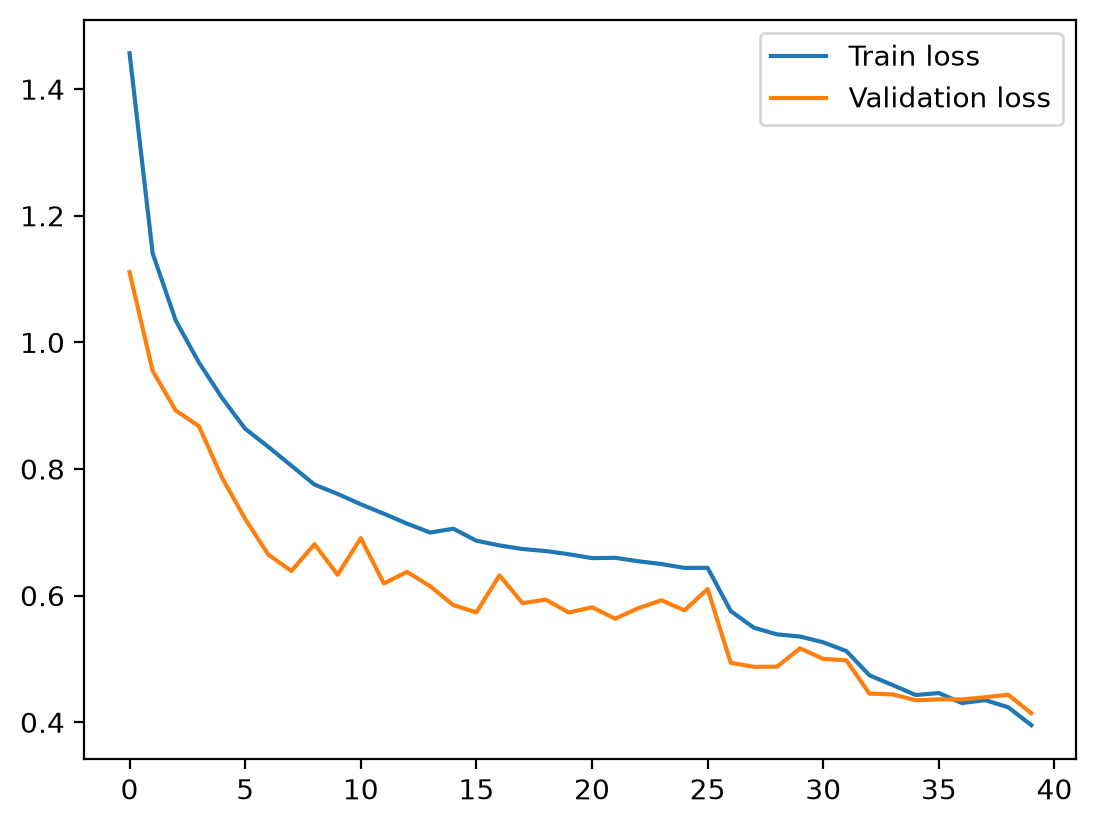

In [ ]:
plt.figure(dpi=200)
plt.plot(np.arange(0, 40), train_loss, label='Train loss')
plt.plot(np.arange(0, 40), valid_loss, label='Validation loss')
plt.legend()
plt.show()

In [ ]:
# Evaluate the trained model on the test set
test_sum_loss = 0
model.eval()
with torch.inference_mode():
    for test_images, test_labels in test_loader:
        test_images = test_images.to('cuda')
        test_labels = test_labels.to('cuda')
        test_predictions = model(test_images)
        test_loss = loss_fn(test_predictions, test_labels)
        test_sum_loss += test_loss.item()
        accuracy.update(test_predictions, test_labels)

avg_test_loss = test_sum_loss/len(test_loader)
acc = accuracy.compute()
print(f'Test loss: {avg_test_loss} | Accuracy: {acc}')
accuracy.reset()

Test loss: 0.4171218869392388 | Accuracy: 0.8610000610351562


## 4. Cosine annealing schedule

Replaces ReduceLROnPlateau with `CosineAnnealingLR` (1e-3 -> 1e-5 over 40 epochs).
Valid accuracy 0.8649, test accuracy 0.8620.

In [ ]:
# Same loop. Change: CosineAnnealingLR, stepped once per epoch.
# Train the model (this time with a cosine annealing LR scheduler)
model = ClassificationCNN().to('cuda')
loss_fn = nn.CrossEntropyLoss().to('cuda')
optimizer = torch.optim.Adam(params=model.parameters(), lr=1e-3, weight_decay=5e-4)
accuracy = MulticlassAccuracy(num_classes=10).to('cuda')
# Instead of ReduceLROnPlateau:
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, 
    T_max=40,       # Number of epochs (must match epochs = 40)
    eta_min=1e-5    # Minimum learning rate reached at the end of training
)

epochs = 40

train_loss = []
valid_loss = []


for epoch in range(epochs):
    train_sum_loss = 0
    val_sum_loss = 0

    model.train()
    for train_images, train_labels in train_loader:
        train_images = train_images.to('cuda')
        train_labels = train_labels.to('cuda')
        train_predictions = model(train_images)
        tr_loss = loss_fn(train_predictions, train_labels)
        optimizer.zero_grad()
        tr_loss.backward()
        optimizer.step()
        train_sum_loss += tr_loss.item()

    model.eval()

    with torch.inference_mode():
        for valid_images, valid_labels in valid_loader:
            valid_images = valid_images.to('cuda')
            valid_labels = valid_labels.to('cuda')
            valid_predictions = model(valid_images)
            val_loss = loss_fn(valid_predictions, valid_labels)
            val_sum_loss += val_loss.item()
            accuracy.update(valid_predictions, valid_labels)

    avg_train_loss = train_sum_loss / len(train_loader)
    avg_val_loss = val_sum_loss / len(valid_loader)
    train_loss.append(avg_train_loss)
    valid_loss.append(avg_val_loss)
    acc = accuracy.compute()

    
    print(f'Epoch: {epoch+1} | Train loss: {avg_train_loss:.4f} | Valid loss: {avg_val_loss:.4f} | Accuracy: {acc:.4f}')

    accuracy.reset()
    scheduler.step()

Epoch: 1 | Train loss: 1.4890 | Valid loss: 1.0825 | Accuracy: 0.6021
Epoch: 2 | Train loss: 1.1507 | Valid loss: 1.0497 | Accuracy: 0.6283
Epoch: 3 | Train loss: 1.0325 | Valid loss: 0.8668 | Accuracy: 0.6924
Epoch: 4 | Train loss: 0.9628 | Valid loss: 0.7885 | Accuracy: 0.7225
Epoch: 5 | Train loss: 0.9044 | Valid loss: 0.7570 | Accuracy: 0.7345
Epoch: 6 | Train loss: 0.8596 | Valid loss: 0.7294 | Accuracy: 0.7504
Epoch: 7 | Train loss: 0.8194 | Valid loss: 0.7014 | Accuracy: 0.7617
Epoch: 8 | Train loss: 0.7951 | Valid loss: 0.6619 | Accuracy: 0.7727
Epoch: 9 | Train loss: 0.7593 | Valid loss: 0.6395 | Accuracy: 0.7762
Epoch: 10 | Train loss: 0.7461 | Valid loss: 0.6367 | Accuracy: 0.7833
Epoch: 11 | Train loss: 0.7157 | Valid loss: 0.6179 | Accuracy: 0.7866
Epoch: 12 | Train loss: 0.7015 | Valid loss: 0.5955 | Accuracy: 0.7952
Epoch: 13 | Train loss: 0.6833 | Valid loss: 0.6158 | Accuracy: 0.7906
Epoch: 14 | Train loss: 0.6657 | Valid loss: 0.5795 | Accuracy: 0.7997
Epoch: 15 | Tra

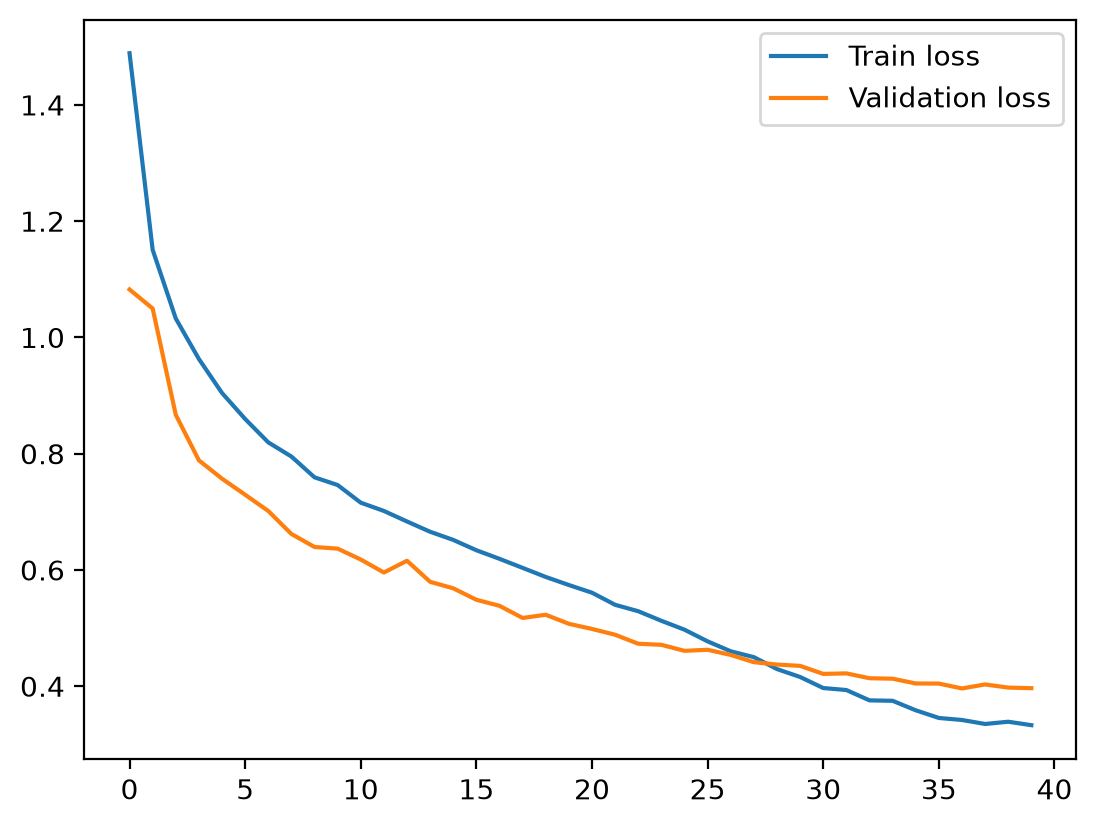

In [ ]:
plt.figure(dpi=200)
plt.plot(np.arange(0, 40), train_loss, label='Train loss')
plt.plot(np.arange(0, 40), valid_loss, label='Validation loss')
plt.legend()
plt.show()

In [ ]:
# Evaluate the trained model on the test set
test_sum_loss = 0
model.eval()
with torch.inference_mode():
    for test_images, test_labels in test_loader:
        test_images = test_images.to('cuda')
        test_labels = test_labels.to('cuda')
        test_predictions = model(test_images)
        test_loss = loss_fn(test_predictions, test_labels)
        test_sum_loss += test_loss.item()
        accuracy.update(test_predictions, test_labels)

avg_test_loss = test_sum_loss/len(test_loader)
acc = accuracy.compute()
print(f'Test loss: {avg_test_loss} | Accuracy: {acc}')
accuracy.reset()

Test loss: 0.4124224262561994 | Accuracy: 0.8619999885559082


## 5. Residual (skip) connections

A custom `ResidualBlock` (conv-BN-ReLU-conv-BN plus a 1x1 projection shortcut when the channel count changes) replaces the plain conv layers. Valid accuracy 0.8708, test accuracy 0.8682.


In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        
        self.in_channels = in_channels
        self.out_channels = out_channels
        
        # Main branch: a plain sequential pipeline (conv - BN - ReLU - conv - BN)
        self.conv_path = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels)
        )
        
        # 1x1 convolution that matches channel counts on the skip path
        self.shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        self.relu = nn.ReLU()

    def forward(self, x):
        identity = x

        # 1. Run the input through the convolutional branch
        out = self.conv_path(x)

        # 2. Project the identity path if the number of channels changes
        if self.in_channels != self.out_channels:
            identity = self.shortcut(identity)

        # 3. Add the branches (the residual / skip connection)
        out = out + identity

        return self.relu(out)


In [ ]:
class ResNetClassificationCNN(nn.Module):
    def __init__(self):
        super().__init__()

        # Stem convolution: RGB (3) -> 16 channels
        self.prep = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU()
        )
        
        # Residual blocks separated by max-pooling
        self.network = nn.Sequential(
            ResidualBlock(16, 32),
            nn.MaxPool2d(2),          # 32x32 -> 16x16
            
            ResidualBlock(32, 64),
            nn.MaxPool2d(2),          # 16x16 -> 8x8
            
            ResidualBlock(64, 128),
            nn.MaxPool2d(2),          # 8x8 -> 4x4
            
            ResidualBlock(128, 256),
            
            nn.AdaptiveAvgPool2d((2, 2)), # 4x4 -> 2x2
            nn.Flatten(),
            nn.Linear(256 * 2 * 2, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.prep(x)
        return self.network(x)

In [ ]:
# Same loop. Change: the residual network (the current learning rate is now printed every epoch).
# Train the residual network with Adam and a cosine scheduler
model = ResNetClassificationCNN().to('cuda')
loss_fn = nn.CrossEntropyLoss().to('cuda')
optimizer = torch.optim.Adam(params=model.parameters(), lr=1e-3, weight_decay=5e-4)
accuracy = MulticlassAccuracy(num_classes=10).to('cuda')

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, 
    T_max=40,       # Number of epochs
    eta_min=1e-5    # Minimum learning rate at the end
)

epochs = 40

train_loss = []
valid_loss = []


for epoch in range(epochs):
    train_sum_loss = 0
    val_sum_loss = 0

    model.train()
    for train_images, train_labels in train_loader:
        train_images = train_images.to('cuda')
        train_labels = train_labels.to('cuda')
        train_predictions = model(train_images)
        tr_loss = loss_fn(train_predictions, train_labels)
        optimizer.zero_grad()
        tr_loss.backward()
        optimizer.step()
        train_sum_loss += tr_loss.item()

    model.eval()

    with torch.inference_mode():
        for valid_images, valid_labels in valid_loader:
            valid_images = valid_images.to('cuda')
            valid_labels = valid_labels.to('cuda')
            valid_predictions = model(valid_images)
            val_loss = loss_fn(valid_predictions, valid_labels)
            val_sum_loss += val_loss.item()
            accuracy.update(valid_predictions, valid_labels)

    avg_train_loss = train_sum_loss / len(train_loader)
    avg_val_loss = val_sum_loss / len(valid_loader)
    train_loss.append(avg_train_loss)
    valid_loss.append(avg_val_loss)
    acc = accuracy.compute()
    
    current_lr = optimizer.param_groups[0]['lr']

    print(f'Epoch: {epoch+1:02d} | Train loss: {avg_train_loss:.4f} | Valid loss: {avg_val_loss:.4f} | Accuracy: {acc:.4f} | LR: {current_lr:.6f}')

    accuracy.reset()
    scheduler.step()

Epoch: 01 | Train loss: 1.5375 | Valid loss: 1.5129 | Accuracy: 0.5049 | LR: 0.001000
Epoch: 02 | Train loss: 1.1560 | Valid loss: 1.0377 | Accuracy: 0.6346 | LR: 0.000998
Epoch: 03 | Train loss: 1.0139 | Valid loss: 0.8766 | Accuracy: 0.6911 | LR: 0.000994
Epoch: 04 | Train loss: 0.9295 | Valid loss: 0.7750 | Accuracy: 0.7208 | LR: 0.000986
Epoch: 05 | Train loss: 0.8694 | Valid loss: 0.7176 | Accuracy: 0.7506 | LR: 0.000976
Epoch: 06 | Train loss: 0.8191 | Valid loss: 0.7163 | Accuracy: 0.7515 | LR: 0.000962
Epoch: 07 | Train loss: 0.7886 | Valid loss: 0.6584 | Accuracy: 0.7714 | LR: 0.000946
Epoch: 08 | Train loss: 0.7589 | Valid loss: 0.6351 | Accuracy: 0.7788 | LR: 0.000927
Epoch: 09 | Train loss: 0.7241 | Valid loss: 0.6511 | Accuracy: 0.7793 | LR: 0.000905
Epoch: 10 | Train loss: 0.7061 | Valid loss: 0.6025 | Accuracy: 0.7948 | LR: 0.000881
Epoch: 11 | Train loss: 0.6841 | Valid loss: 0.6120 | Accuracy: 0.7973 | LR: 0.000855
Epoch: 12 | Train loss: 0.6666 | Valid loss: 0.6044 | 

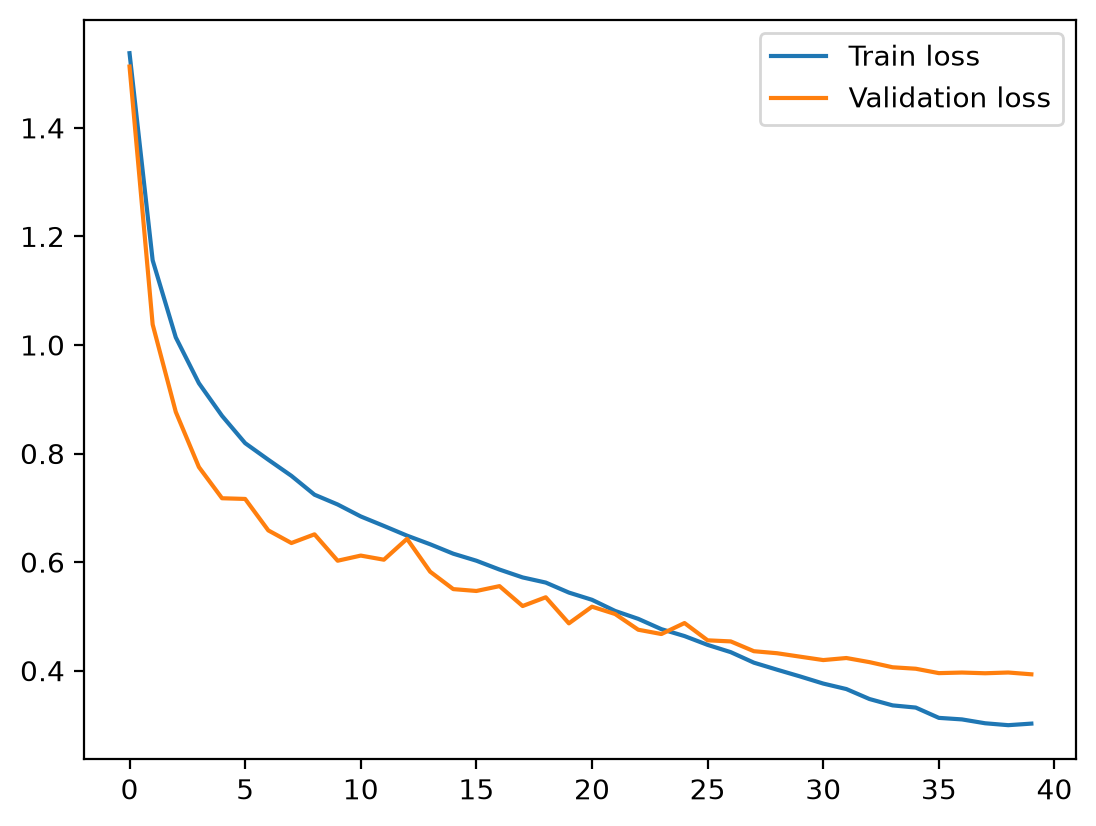

In [ ]:
plt.figure(dpi=200)
plt.plot(np.arange(0, 40), train_loss, label='Train loss')
plt.plot(np.arange(0, 40), valid_loss, label='Validation loss')
plt.legend()
plt.show()

In [ ]:
# Evaluate the trained model on the test set
test_sum_loss = 0
model.eval()
with torch.inference_mode():
    for test_images, test_labels in test_loader:
        test_images = test_images.to('cuda')
        test_labels = test_labels.to('cuda')
        test_predictions = model(test_images)
        test_loss = loss_fn(test_predictions, test_labels)
        test_sum_loss += test_loss.item()
        accuracy.update(test_predictions, test_labels)

avg_test_loss = test_sum_loss/len(test_loader)
acc = accuracy.compute()
print(f'Test loss: {avg_test_loss} | Accuracy: {acc}')
accuracy.reset()

Test loss: 0.39891672348038265 | Accuracy: 0.8681999444961548


## 6. Same residual network, SGD + momentum

SGD (lr 0.1, momentum 0.9, weight decay 5e-4) with a cosine schedule over 80 epochs.
Valid accuracy 0.8816, test accuracy 0.8784.

In [ ]:
# Same loop. Change: SGD (lr=0.1, momentum=0.9), 80 epochs.
# Same network, now optimized with SGD + momentum for 80 epochs
model = ResNetClassificationCNN().to('cuda')
loss_fn = nn.CrossEntropyLoss().to('cuda')
optimizer = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
accuracy = MulticlassAccuracy(num_classes=10).to('cuda')

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, 
    T_max=80,       # Number of epochs
    eta_min=1e-5    # Minimum learning rate at the end
)

epochs = 80

train_loss = []
valid_loss = []


for epoch in range(epochs):
    train_sum_loss = 0
    val_sum_loss = 0

    model.train()
    for train_images, train_labels in train_loader:
        train_images = train_images.to('cuda')
        train_labels = train_labels.to('cuda')
        train_predictions = model(train_images)
        tr_loss = loss_fn(train_predictions, train_labels)
        optimizer.zero_grad()
        tr_loss.backward()
        optimizer.step()
        train_sum_loss += tr_loss.item()

    model.eval()

    with torch.inference_mode():
        for valid_images, valid_labels in valid_loader:
            valid_images = valid_images.to('cuda')
            valid_labels = valid_labels.to('cuda')
            valid_predictions = model(valid_images)
            val_loss = loss_fn(valid_predictions, valid_labels)
            val_sum_loss += val_loss.item()
            accuracy.update(valid_predictions, valid_labels)

    avg_train_loss = train_sum_loss / len(train_loader)
    avg_val_loss = val_sum_loss / len(valid_loader)
    train_loss.append(avg_train_loss)
    valid_loss.append(avg_val_loss)
    acc = accuracy.compute()
    
    current_lr = optimizer.param_groups[0]['lr']

    print(f'Epoch: {epoch+1:02d} | Train loss: {avg_train_loss:.4f} | Valid loss: {avg_val_loss:.4f} | Accuracy: {acc:.4f} | LR: {current_lr:.6f}')

    accuracy.reset()
    scheduler.step()

Epoch: 01 | Train loss: 1.8985 | Valid loss: 1.5890 | Accuracy: 0.3960 | LR: 0.100000
Epoch: 02 | Train loss: 1.5743 | Valid loss: 1.5108 | Accuracy: 0.4554 | LR: 0.099961
Epoch: 03 | Train loss: 1.4445 | Valid loss: 1.3574 | Accuracy: 0.5373 | LR: 0.099846
Epoch: 04 | Train loss: 1.3641 | Valid loss: 1.4576 | Accuracy: 0.5202 | LR: 0.099653
Epoch: 05 | Train loss: 1.3270 | Valid loss: 1.4006 | Accuracy: 0.5360 | LR: 0.099384
Epoch: 06 | Train loss: 1.3046 | Valid loss: 1.2510 | Accuracy: 0.5655 | LR: 0.099039
Epoch: 07 | Train loss: 1.2900 | Valid loss: 1.1111 | Accuracy: 0.6160 | LR: 0.098619
Epoch: 08 | Train loss: 1.2652 | Valid loss: 1.6258 | Accuracy: 0.5310 | LR: 0.098123
Epoch: 09 | Train loss: 1.2435 | Valid loss: 1.0667 | Accuracy: 0.6321 | LR: 0.097553
Epoch: 10 | Train loss: 1.2381 | Valid loss: 1.4942 | Accuracy: 0.5148 | LR: 0.096910
Epoch: 11 | Train loss: 1.2342 | Valid loss: 1.3055 | Accuracy: 0.5922 | LR: 0.096194
Epoch: 12 | Train loss: 1.2259 | Valid loss: 1.1399 | 

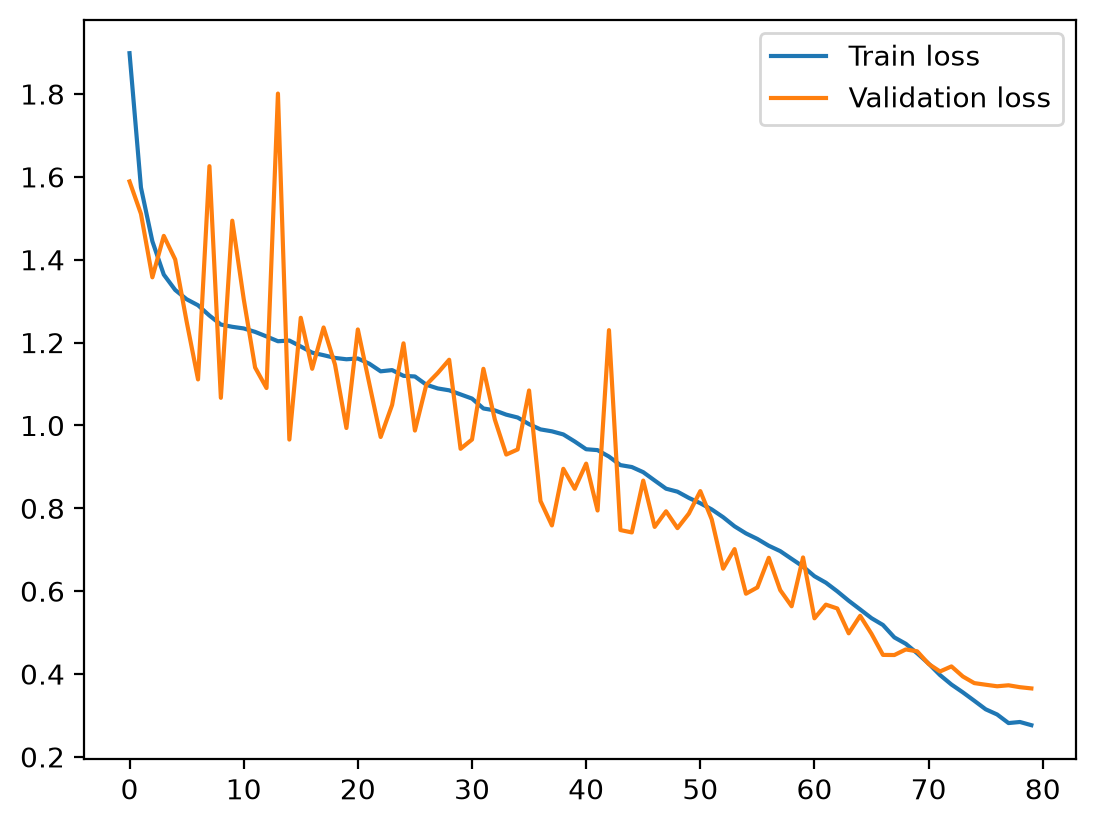

In [ ]:
plt.figure(dpi=200)
plt.plot(np.arange(0, 80), train_loss, label='Train loss')
plt.plot(np.arange(0, 80), valid_loss, label='Validation loss')
plt.legend()
plt.show()

In [ ]:
# Evaluate the trained model on the test set
test_sum_loss = 0
model.eval()
with torch.inference_mode():
    for test_images, test_labels in test_loader:
        test_images = test_images.to('cuda')
        test_labels = test_labels.to('cuda')
        test_predictions = model(test_images)
        test_loss = loss_fn(test_predictions, test_labels)
        test_sum_loss += test_loss.item()
        accuracy.update(test_predictions, test_labels)

avg_test_loss = test_sum_loss/len(test_loader)
acc = accuracy.compute()
print(f'Test loss: {avg_test_loss} | Accuracy: {acc}')
accuracy.reset()

Test loss: 0.3674944056430088 | Accuracy: 0.8783999681472778


## 7. Deeper residual network (ResNet-18-style)

Four stages with two residual blocks each (32 / 64 / 128 / 256 channels), BatchNorm on the shortcut and no conv bias. Valid accuracy 0.8927, test accuracy 0.8907.


In [ ]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        
        self.in_channels = in_channels
        self.out_channels = out_channels
        
        self.conv_path = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels)
        )
        
        self.shortcut = nn.Sequential()
        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
                nn.BatchNorm2d(out_channels)
            )
            
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(self.conv_path(x) + self.shortcut(x))

In [ ]:
class ResNet18CIFAR(nn.Module):
    def __init__(self):
        super().__init__()

        # Stem layer: RGB (3) -> 16 channels
        self.prep = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU()
        )
        
        # Stage 1: 16 -> 32 channels (32x32)
        self.stage1 = nn.Sequential(
            ResidualBlock(16, 32),
            ResidualBlock(32, 32)
        )
        self.pool1 = nn.MaxPool2d(2) # 32x32 -> 16x16
        
        # Stage 2: 32 -> 64 channels (16x16)
        self.stage2 = nn.Sequential(
            ResidualBlock(32, 64),
            ResidualBlock(64, 64)
        )
        self.pool2 = nn.MaxPool2d(2) # 16x16 -> 8x8
        
        # Stage 3: 64 -> 128 channels (8x8)
        self.stage3 = nn.Sequential(
            ResidualBlock(64, 128),
            ResidualBlock(128, 128)
        )
        self.pool3 = nn.MaxPool2d(2) # 8x8 -> 4x4
        
        # Stage 4: 128 -> 256 channels (4x4)
        self.stage4 = nn.Sequential(
            ResidualBlock(128, 256),
            ResidualBlock(256, 256)
        )

        # Classifier head
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((2, 2)),
            nn.Flatten(),
            nn.Linear(256 * 2 * 2, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.prep(x)
        
        x = self.stage1(x)
        x = self.pool1(x)
        
        x = self.stage2(x)
        x = self.pool2(x)
        
        x = self.stage3(x)
        x = self.pool3(x)
        
        x = self.stage4(x)
        
        return self.classifier(x)

In [ ]:
# Same loop. Change: the deeper ResNet-18-style network.
# Train the ResNet-18-style network with SGD + momentum and a cosine scheduler
model = ResNet18CIFAR().to('cuda')
loss_fn = nn.CrossEntropyLoss().to('cuda')

# SGD + momentum (the classic choice for deep ResNets)
optimizer = torch.optim.SGD(model.parameters(), lr=0.1, momentum=0.9, weight_decay=5e-4)
accuracy = MulticlassAccuracy(num_classes=10).to('cuda')

epochs = 80

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, 
    T_max=epochs,    # One full cosine cycle over all 80 epochs
    eta_min=1e-5     # Minimum learning rate at the end
)

train_loss = []
valid_loss = []


for epoch in range(epochs):
    train_sum_loss = 0
    val_sum_loss = 0

    model.train()
    for train_images, train_labels in train_loader:
        train_images = train_images.to('cuda')
        train_labels = train_labels.to('cuda')
        train_predictions = model(train_images)
        tr_loss = loss_fn(train_predictions, train_labels)
        optimizer.zero_grad()
        tr_loss.backward()
        optimizer.step()
        train_sum_loss += tr_loss.item()

    model.eval()

    with torch.inference_mode():
        for valid_images, valid_labels in valid_loader:
            valid_images = valid_images.to('cuda')
            valid_labels = valid_labels.to('cuda')
            valid_predictions = model(valid_images)
            val_loss = loss_fn(valid_predictions, valid_labels)
            val_sum_loss += val_loss.item()
            accuracy.update(valid_predictions, valid_labels)

    avg_train_loss = train_sum_loss / len(train_loader)
    avg_val_loss = val_sum_loss / len(valid_loader)
    train_loss.append(avg_train_loss)
    valid_loss.append(avg_val_loss)
    acc = accuracy.compute()

    current_lr = optimizer.param_groups[0]['lr']

    print(f'Epoch: {epoch+1:02d} | Train loss: {avg_train_loss:.4f} | Valid loss: {avg_val_loss:.4f} | Accuracy: {acc:.4f} | LR: {current_lr:.6f}')

    accuracy.reset()
    scheduler.step()

Epoch: 01 | Train loss: 1.9587 | Valid loss: 1.5649 | Accuracy: 0.4102 | LR: 0.100000
Epoch: 02 | Train loss: 1.6164 | Valid loss: 1.4506 | Accuracy: 0.4672 | LR: 0.099961
Epoch: 03 | Train loss: 1.4204 | Valid loss: 1.3847 | Accuracy: 0.5308 | LR: 0.099846
Epoch: 04 | Train loss: 1.3009 | Valid loss: 1.3355 | Accuracy: 0.5580 | LR: 0.099653
Epoch: 05 | Train loss: 1.2415 | Valid loss: 1.2205 | Accuracy: 0.5643 | LR: 0.099384
Epoch: 06 | Train loss: 1.2004 | Valid loss: 1.0092 | Accuracy: 0.6420 | LR: 0.099039
Epoch: 07 | Train loss: 1.1654 | Valid loss: 1.6509 | Accuracy: 0.5241 | LR: 0.098619
Epoch: 08 | Train loss: 1.1579 | Valid loss: 1.1226 | Accuracy: 0.6331 | LR: 0.098123
Epoch: 09 | Train loss: 1.1392 | Valid loss: 1.3201 | Accuracy: 0.5762 | LR: 0.097553
Epoch: 10 | Train loss: 1.1170 | Valid loss: 1.0043 | Accuracy: 0.6610 | LR: 0.096910
Epoch: 11 | Train loss: 1.0958 | Valid loss: 0.9292 | Accuracy: 0.6834 | LR: 0.096194
Epoch: 12 | Train loss: 1.0972 | Valid loss: 0.9719 | 

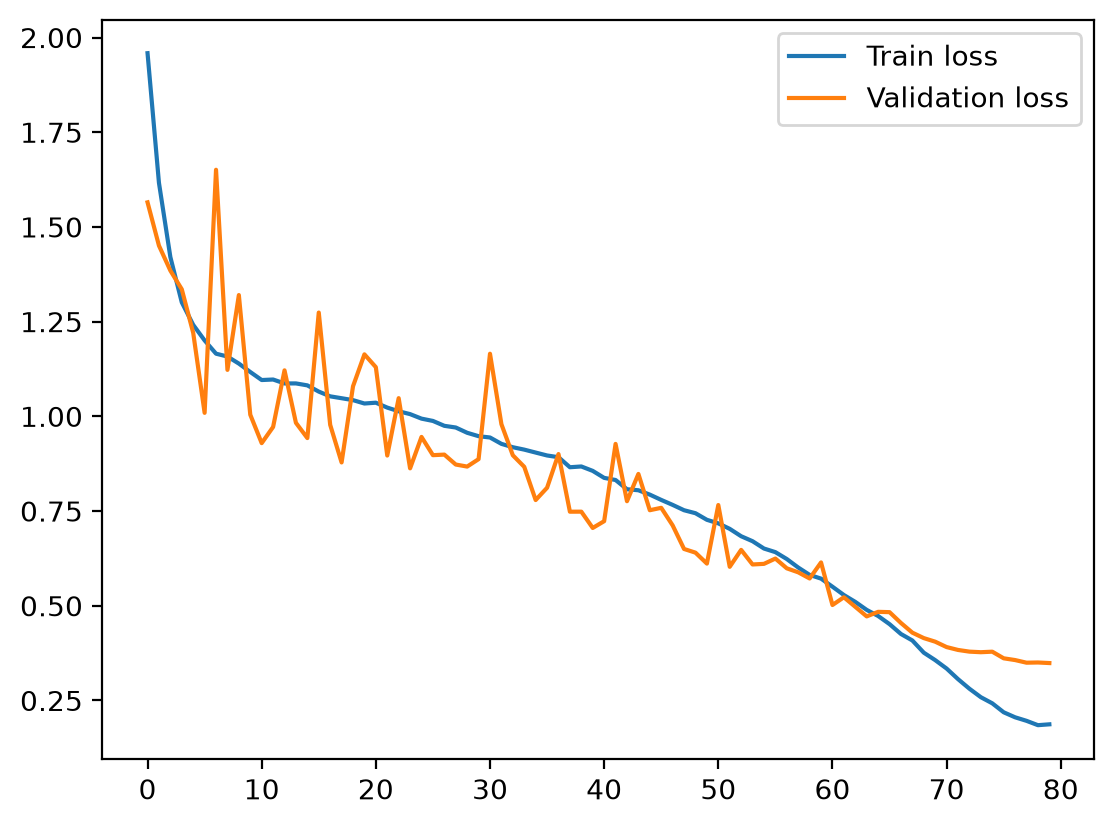

In [ ]:
plt.figure(dpi=200)
plt.plot(np.arange(0, 80), train_loss, label='Train loss')
plt.plot(np.arange(0, 80), valid_loss, label='Validation loss')
plt.legend()
plt.show()

In [ ]:
# Evaluate the trained model on the test set
test_sum_loss = 0
model.eval()
with torch.inference_mode():
    for test_images, test_labels in test_loader:
        test_images = test_images.to('cuda')
        test_labels = test_labels.to('cuda')
        test_predictions = model(test_images)
        test_loss = loss_fn(test_predictions, test_labels)
        test_sum_loss += test_loss.item()
        accuracy.update(test_predictions, test_labels)

avg_test_loss = test_sum_loss/len(test_loader)
acc = accuracy.compute()
print(f'Test loss: {avg_test_loss} | Accuracy: {acc}')
accuracy.reset()


Test loss: 0.3547886200011157 | Accuracy: 0.8906999826431274


## 8. Transfer learning: ResNet-18 pretrained on ImageNet

All layers are fine-tuned. CIFAR images are upscaled from 32x32 to 224x224 and normalized with ImageNet statistics. 10 epochs with Adam and a cosine schedule: valid accuracy 0.9203, test accuracy 0.9115 -- the best result in this notebook.


In [ ]:
# Load ResNet-18 with ImageNet weights and replace the last layer with a 10-class head
import torchvision
from torchvision.models import ResNet18_Weights
weights = ResNet18_Weights.DEFAULT
model_resnet = torchvision.models.resnet18(weights=weights)
model_resnet.fc = torch.nn.Linear(model_resnet.fc.in_features, 10)

In [ ]:
# (re-import of the accuracy metric)
from torchmetrics.classification import MulticlassAccuracy

In [ ]:
# Build the transform pipelines for the pretrained network
transform_train = transforms.Compose([

    # Convert to a PyTorch tensor (pixel values 0.0 - 1.0)
        transforms.ToTensor(),

        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomCrop(32, padding=4),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.RandomErasing(p=0.25, scale=(0.02, 0.2), value='random'),
    # Upscale 32x32 -> 224x224 (the input size the pretrained network expects)
    transforms.Resize((224, 224)),
    
    
    
    # Normalize with the ImageNet mean / std
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406], 
        std=[0.229, 0.224, 0.225]
    )
])

transform_valid = transforms.Compose([
    # Upscale 32x32 -> 224x224 (the input size the pretrained network expects)
    transforms.Resize((224, 224)),
    
    # Convert to a PyTorch tensor (pixel values 0.0 - 1.0)
    transforms.ToTensor(),
    
    # Normalize with the ImageNet mean / std
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406], 
        std=[0.229, 0.224, 0.225]
    )
])

transform_test = transforms.Compose([
    # Upscale 32x32 -> 224x224 (the input size the pretrained network expects)
    transforms.Resize((224, 224)),
    
    # Convert to a PyTorch tensor (pixel values 0.0 - 1.0)
    transforms.ToTensor(),
    
    # Normalize with the ImageNet mean / std
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406], 
        std=[0.229, 0.224, 0.225]
    )
])



In [ ]:
from torch.utils.data import DataLoader, random_split
# 2. Load the image folders, each with its own transforms
ds_train_full = datasets.ImageFolder(TRAIN_DATA_PATH, transform=transform_train)
ds_valid_full = datasets.ImageFolder(TRAIN_DATA_PATH, transform=transform_valid)

# 3. Fix the random seed so that both splits use the same indices
generator = torch.Generator().manual_seed(42)

# 4. Split: the 80% part comes from the augmented dataset (train), the 20% part from the plain one (valid)
train_dataset, _ = random_split(
    ds_train_full, 
    [0.8, 0.2], 
    generator=torch.Generator().manual_seed(42)
)

_, valid_dataset = random_split(
    ds_valid_full, 
    [0.8, 0.2], 
    generator=torch.Generator().manual_seed(42) # Reset to the same seed (42) so the indices match the train split
)

test_dataset = datasets.ImageFolder(TEST_DATA_PATH, transform=transform_valid)

# 5. Data loaders
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

In [ ]:
# Same loop. Changes: pretrained ResNet-18 at 224x224, Adam (lr=1e-3), batch size 128, 10 epochs.
# Fine-tune the pretrained ResNet-18 (all layers) with Adam and a cosine scheduler
model = model_resnet.to('cuda')
loss_fn = nn.CrossEntropyLoss().to('cuda')


optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
accuracy = MulticlassAccuracy(num_classes=10).to('cuda')

epochs = 10

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, 
    T_max=epochs,    
    eta_min=1e-5     
)

train_loss = []
valid_loss = []


for epoch in range(epochs):
    train_sum_loss = 0
    val_sum_loss = 0

    model.train()
    for train_images, train_labels in train_loader:
        train_images = train_images.to('cuda')
        train_labels = train_labels.to('cuda')
        train_predictions = model(train_images)
        tr_loss = loss_fn(train_predictions, train_labels)
        optimizer.zero_grad()
        tr_loss.backward()
        optimizer.step()
        train_sum_loss += tr_loss.item()

    model.eval()

    with torch.inference_mode():
        for valid_images, valid_labels in valid_loader:
            valid_images = valid_images.to('cuda')
            valid_labels = valid_labels.to('cuda')
            valid_predictions = model(valid_images)
            val_loss = loss_fn(valid_predictions, valid_labels)
            val_sum_loss += val_loss.item()
            accuracy.update(valid_predictions, valid_labels)

    avg_train_loss = train_sum_loss / len(train_loader)
    avg_val_loss = val_sum_loss / len(valid_loader)
    train_loss.append(avg_train_loss)
    valid_loss.append(avg_val_loss)
    acc = accuracy.compute()

    current_lr = optimizer.param_groups[0]['lr']

    print(f'Epoch: {epoch+1:02d} | Train loss: {avg_train_loss:.4f} | Valid loss: {avg_val_loss:.4f} | Accuracy: {acc:.4f} | LR: {current_lr:.6f}')

    accuracy.reset()
    scheduler.step()

Epoch: 01 | Train loss: 0.8366 | Valid loss: 0.6949 | Accuracy: 0.7566 | LR: 0.001000
Epoch: 02 | Train loss: 0.5896 | Valid loss: 0.6460 | Accuracy: 0.7866 | LR: 0.000976
Epoch: 03 | Train loss: 0.5008 | Valid loss: 0.6038 | Accuracy: 0.8045 | LR: 0.000905
Epoch: 04 | Train loss: 0.4326 | Valid loss: 0.5788 | Accuracy: 0.8185 | LR: 0.000796
Epoch: 05 | Train loss: 0.3672 | Valid loss: 0.4288 | Accuracy: 0.8617 | LR: 0.000658
Epoch: 06 | Train loss: 0.3085 | Valid loss: 0.3414 | Accuracy: 0.8841 | LR: 0.000505
Epoch: 07 | Train loss: 0.2426 | Valid loss: 0.3046 | Accuracy: 0.8978 | LR: 0.000352
Epoch: 08 | Train loss: 0.1821 | Valid loss: 0.2836 | Accuracy: 0.9073 | LR: 0.000214
Epoch: 09 | Train loss: 0.1350 | Valid loss: 0.2584 | Accuracy: 0.9143 | LR: 0.000105
Epoch: 10 | Train loss: 0.1105 | Valid loss: 0.2430 | Accuracy: 0.9203 | LR: 0.000034


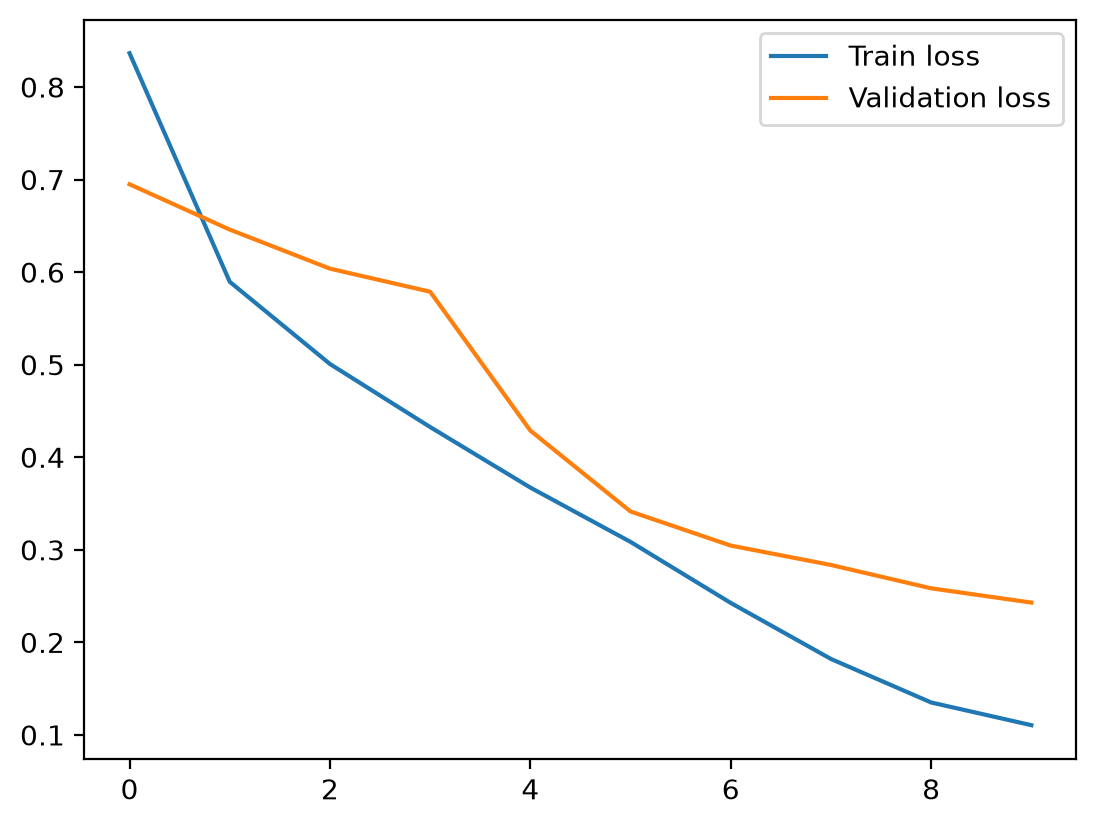

In [ ]:
plt.figure(dpi=200)
plt.plot(np.arange(0, 10), train_loss, label='Train loss')
plt.plot(np.arange(0, 10), valid_loss, label='Validation loss')
plt.legend()
plt.show()

In [ ]:
# Evaluate the trained model on the test set
test_sum_loss = 0
model.eval()
with torch.inference_mode():
    for test_images, test_labels in test_loader:
        test_images = test_images.to('cuda')
        test_labels = test_labels.to('cuda')
        test_predictions = model(test_images)
        test_loss = loss_fn(test_predictions, test_labels)
        test_sum_loss += test_loss.item()
        accuracy.update(test_predictions, test_labels)

avg_test_loss = test_sum_loss/len(test_loader)
acc = accuracy.compute()
print(f'Test loss: {avg_test_loss} | Accuracy: {acc}')
accuracy.reset()

Test loss: 0.27047214492023747 | Accuracy: 0.9114999771118164


## 9. Freezing layers (interrupted run)

Freezes everything up to and including `layer3` of ResNet-18 and trains only `layer4` and the new classifier. 20 epochs were logged (valid accuracy 0.8907 at the last one) before the Jupyter kernel crashed, so there is no test evaluation and the loss-curve output was removed.


In [ ]:
# Reload a fresh pretrained ResNet-18 with a new 10-class head
import torchvision
from torchvision.models import ResNet18_Weights
weights = ResNet18_Weights.DEFAULT
model_resnet = torchvision.models.resnet18(weights=weights)
model_resnet.fc = nn.Linear(512, 10)
model_resnet.parameters

In [ ]:
# Freeze the first 7 children (conv1, bn1, relu, maxpool, layer1, layer2, layer3);
# layer4, avgpool and the new fc layer stay trainable
layers = list(model_resnet.children())
for i in range(7):
    for param in layers[i].parameters():
        param.requires_grad = False

frozen_part = nn.Sequential(*list(model_resnet.children())[:7])
trainable_part = nn.Sequential(*list(model_resnet.children())[7:])

In [ ]:
# Number of top-level children of ResNet-18
len(layers)

10

In [ ]:
# Same loop. Change: only the unfrozen part (layer4 + fc) is optimized, 20 epochs.
# The Jupyter kernel crashed during this run (after 20 epochs were logged); no test evaluation was run.
# Fine-tune the pretrained ResNet-18 with the first 7 children frozen
model = model_resnet.to('cuda')
loss_fn = nn.CrossEntropyLoss().to('cuda')


optimizer = torch.optim.Adam(params=trainable_part.parameters(), lr=1e-3)
accuracy = MulticlassAccuracy(num_classes=10).to('cuda')

epochs = 20

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, 
    T_max=epochs,    # One full cosine cycle over all 20 epochs
    eta_min=1e-5     # Minimum learning rate at the end
)

train_loss = []
valid_loss = []


for epoch in range(epochs):
    train_sum_loss = 0
    val_sum_loss = 0

    model.train()
    for train_images, train_labels in train_loader:
        train_images = train_images.to('cuda')
        train_labels = train_labels.to('cuda')
        train_predictions = model(train_images)
        tr_loss = loss_fn(train_predictions, train_labels)
        optimizer.zero_grad()
        tr_loss.backward()
        optimizer.step()
        train_sum_loss += tr_loss.item()

    model.eval()

    with torch.inference_mode():
        for valid_images, valid_labels in valid_loader:
            valid_images = valid_images.to('cuda')
            valid_labels = valid_labels.to('cuda')
            valid_predictions = model(valid_images)
            val_loss = loss_fn(valid_predictions, valid_labels)
            val_sum_loss += val_loss.item()
            accuracy.update(valid_predictions, valid_labels)

    avg_train_loss = train_sum_loss / len(train_loader)
    avg_val_loss = val_sum_loss / len(valid_loader)
    train_loss.append(avg_train_loss)
    valid_loss.append(avg_val_loss)
    acc = accuracy.compute()

    current_lr = optimizer.param_groups[0]['lr']

    print(f'Epoch: {epoch+1:02d} | Train loss: {avg_train_loss:.4f} | Valid loss: {avg_val_loss:.4f} | Accuracy: {acc:.4f} | LR: {current_lr:.6f}')

    accuracy.reset()
    scheduler.step()

In [ ]:
# Loss curves of the frozen-layers run (the original cell plotted np.arange(0, 100); changed to `epochs` so it matches the 20-epoch run)
plt.figure(dpi=200)
plt.plot(np.arange(0, epochs), train_loss, label='Train loss')
plt.plot(np.arange(0, epochs), valid_loss, label='Validation loss')
plt.legend()
plt.show()


## 10. DenseNet-121 pretrained (not completed)

The cells below load DenseNet-121 and set up training, but the training run was never completed, so no results are recorded here.


In [ ]:
# Load DenseNet-121 pretrained on ImageNet (torch.hub) and replace the classifier with a 10-class head
model_densenet = torch.hub.load('pytorch/vision:v0.10.0', 'densenet121', pretrained=True, memory_efficient=True)
model_densenet.classifier = torch.nn.Linear(1024, 10)

In [ ]:
# 2. Load the image folders, each with its own transforms
ds_train_full = datasets.ImageFolder(TRAIN_DATA_PATH, transform=transform_train)
ds_valid_full = datasets.ImageFolder(TRAIN_DATA_PATH, transform=transform_valid)

# 3. Fix the random seed so that both splits use the same indices
generator = torch.Generator().manual_seed(42)

# 4. Split: the 80% part comes from the augmented dataset (train), the 20% part from the plain one (valid)
train_dataset, _ = random_split(
    ds_train_full, 
    [0.8, 0.2], 
    generator=torch.Generator().manual_seed(42)
)

_, valid_dataset = random_split(
    ds_valid_full, 
    [0.8, 0.2], 
    generator=torch.Generator().manual_seed(42) # Reset to the same seed (42) so the indices match the train split
)

test_dataset = datasets.ImageFolder(TEST_DATA_PATH, transform=transform_valid)

# 5. Data loaders
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

In [ ]:
# (inspection only)
model_densenet.parameters

In [ ]:
import gc
import torch

# Free unused Python objects and cached GPU memory
gc.collect()
torch.cuda.empty_cache()

In [ ]:
# NOT COMPLETED: this run was never finished, so no results were recorded.
# Fine-tune the pretrained DenseNet-121 with Adam and a cosine scheduler
model = model_densenet.to('cuda')
loss_fn = nn.CrossEntropyLoss().to('cuda')

# Optimizer: Adam
optimizer = torch.optim.Adam(params=model.parameters(), lr=1e-3)
accuracy = MulticlassAccuracy(num_classes=10).to('cuda')

epochs = 10

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, 
    T_max=epochs,    # One full cosine cycle over all epochs
    eta_min=1e-5     # Minimum learning rate at the end
)

train_loss = []
valid_loss = []


for epoch in range(epochs):
    train_sum_loss = 0
    val_sum_loss = 0

    model.train()
    for train_images, train_labels in train_loader:
        train_images = train_images.to('cuda')
        train_labels = train_labels.to('cuda')
        train_predictions = model(train_images)
        tr_loss = loss_fn(train_predictions, train_labels)
        optimizer.zero_grad()
        tr_loss.backward()
        optimizer.step()
        train_sum_loss += tr_loss.item()

    model.eval()

    with torch.inference_mode():
        for valid_images, valid_labels in valid_loader:
            valid_images = valid_images.to('cuda')
            valid_labels = valid_labels.to('cuda')
            valid_predictions = model(valid_images)
            val_loss = loss_fn(valid_predictions, valid_labels)
            val_sum_loss += val_loss.item()
            accuracy.update(valid_predictions, valid_labels)

    avg_train_loss = train_sum_loss / len(train_loader)
    avg_val_loss = val_sum_loss / len(valid_loader)
    train_loss.append(avg_train_loss)
    valid_loss.append(avg_val_loss)
    acc = accuracy.compute()

    current_lr = optimizer.param_groups[0]['lr']

    print(f'Epoch: {epoch+1:02d} | Train loss: {avg_train_loss:.4f} | Valid loss: {avg_val_loss:.4f} | Accuracy: {acc:.4f} | LR: {current_lr:.6f}')

    accuracy.reset()
    scheduler.step()

In [ ]:
plt.figure(dpi=200)
plt.plot(np.arange(0, 10), train_loss, label='Train loss')
plt.plot(np.arange(0, 10), valid_loss, label='Validation loss')
plt.legend()
plt.show()

In [ ]:
# Evaluate the trained model on the test set
test_sum_loss = 0
model.eval()
with torch.inference_mode():
    for test_images, test_labels in test_loader:
        test_images = test_images.to('cuda')
        test_labels = test_labels.to('cuda')
        test_predictions = model(test_images)
        test_loss = loss_fn(test_predictions, test_labels)
        test_sum_loss += test_loss.item()
        accuracy.update(test_predictions, test_labels)

avg_test_loss = test_sum_loss/len(test_loader)
acc = accuracy.compute()
print(f'Test loss: {avg_test_loss} | Accuracy: {acc}')
accuracy.reset()